# EDA — Pima Indians Diabetes
Exploratory analysis of the raw dataset used by the pipeline (Stage 1 input).

In [2]:
from pathlib import Path
import pandas as pd

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(project_dir / "data" / "raw" / "pima-indians-diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Class                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# class balance
df["Class"].value_counts(normalize=True)

Class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [6]:
# hidden missing values: physiologically impossible zeros
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    print(col, "— zeros:", (df[col] == 0).sum())

Glucose — zeros: 5
BloodPressure — zeros: 35
SkinThickness — zeros: 227
Insulin — zeros: 374
BMI — zeros: 11


In [8]:
df.groupby("Class")[["Glucose", "BMI", "Age", "Insulin"]].mean()

,Glucose,BMI,Age,Insulin
Class,,,,
0,109.980000,30.304200,31.190000,68.792000
1,141.257463,35.142537,37.067164,100.335821


array([[<Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Insulin'}>]], dtype=object)

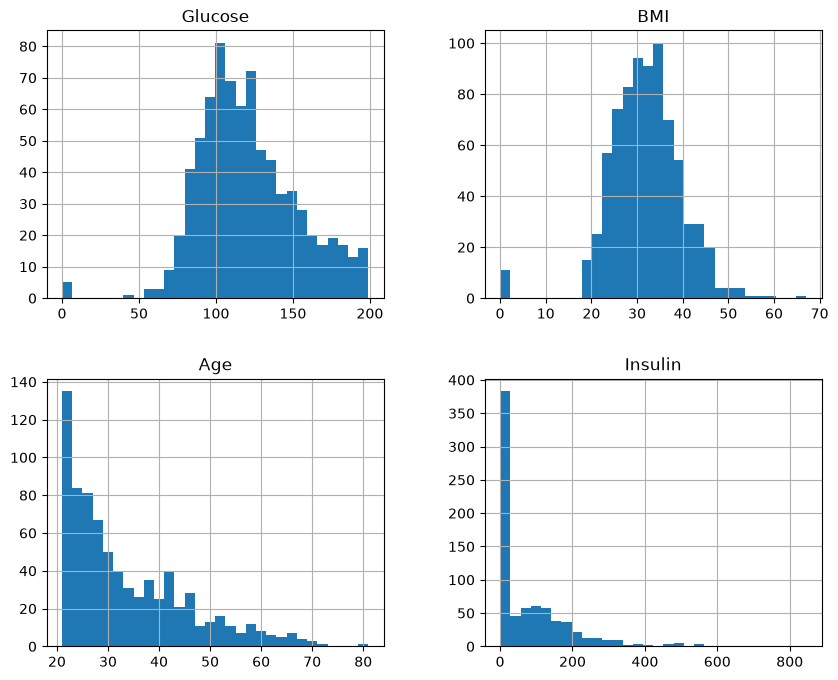

In [9]:
df[["Glucose", "BMI", "Age", "Insulin"]].hist(bins=30, figsize=(10, 8))